In [11]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

sys.path.append('C:\\Users\\evils\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData

experiment_data = ExperimentData()
experiment_data.get_experiment_data(
    fuel_name='diesel',
    additive_name='steam',
    component_name='CO'
)
print(experiment_data.df)

    F_fuel  F_steam      CO
0     0.50      0.2  500.00
1     0.60      0.2   26.40
2     0.60      0.4  500.00
3     0.65      0.4  500.00
4     0.70      0.2   14.90
5     0.70      0.4   32.05
6     0.70      0.6  500.00
7     0.75      0.6  500.00
8     0.80      0.2    8.55
9     0.80      0.4   49.30
10    0.80      0.6  194.05
11    0.80      0.8  500.00
12    0.90      0.2   43.20
13    0.90      0.6   40.10
14    0.95      0.2  500.00
15    1.00      0.4   18.25
16    1.00      0.6   12.50
17    1.00      0.8  135.45
18    1.00      1.0  500.00
19    1.10      0.2  500.00
20    1.10      0.4  230.10
21    1.10      0.6   13.30
22    1.10      0.8  255.90
23    1.10      1.1  500.00
24    1.15      1.0  500.00
25    1.20      0.4  500.00
26    1.20      0.6    5.35
27    1.20      0.8    6.70
28    1.20      1.0  129.40
29    1.20      1.2  500.00
30    1.25      0.6   46.80
31    1.30      0.8    6.80
32    1.30      1.0    6.60
33    1.35      0.6  500.00
34    1.40      0.6 

In [20]:
x, y, z = experiment_data.get_rbf_data(
    med_filter=False,
    non_zero=False
)
x1, y1, z1 = experiment_data.get_rbf_data(
    med_filter=True,
    non_zero=True
)

Text(0.5, 1.0, 'RBF')

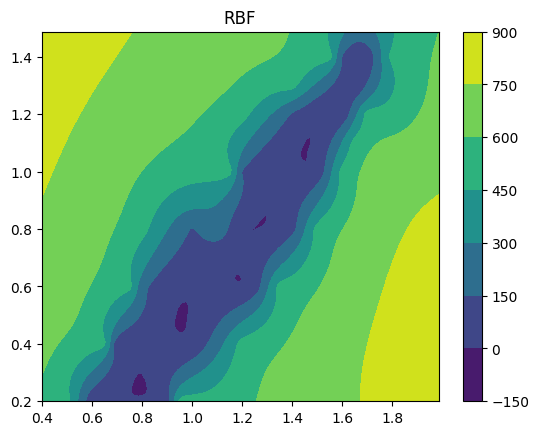

In [22]:
plt.contourf(x, y, z)
plt.colorbar()
plt.title('RBF')

Text(0.5, 1.0, 'RBF c постобработкой')

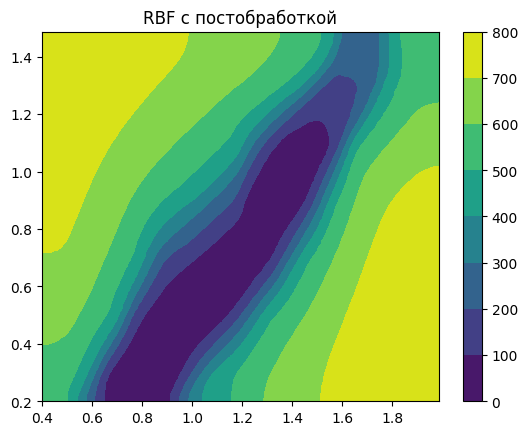

In [24]:
plt.contourf(x1, y1, z1)
plt.colorbar()
plt.title('RBF c постобработкой')

In [52]:
from scipy.interpolate import SmoothBivariateSpline, RectBivariateSpline

x_ex, y_ex, z_ex = list(experiment_data.df['F_fuel']), list(experiment_data.df['F_steam']), list(experiment_data.df['CO'])

spline = RectBivariateSpline(x_ex, y_ex, z_ex, s=2)

x_new = np.linspace(min(x_ex), max(x_ex), 100)
y_new = np.linspace(min(y_ex), max(y_ex), 100)
z_new = spline(x_new, y_new)

ValueError: x must be strictly increasing

Text(0.5, 1.0, 'RBF c постобработкой')

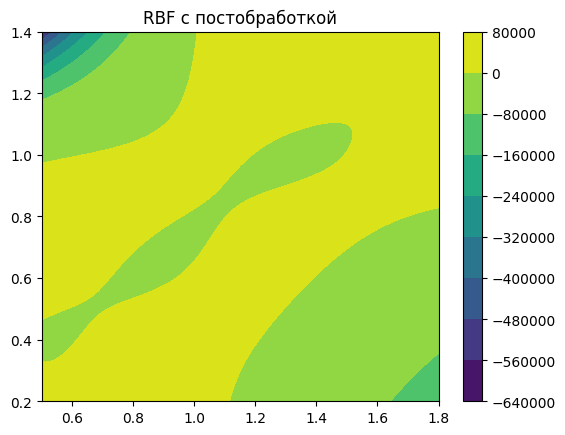

In [51]:
plt.contourf(x_new, y_new, z_new)
plt.colorbar()
plt.title('RBF c постобработкой')